# AIFM Hedge Fund — Risk Notebook

AIFM Risk limits are defined in the fund's offering document and monitored against
internal thresholds. No regulatory VaR limit applies (unlike UCITS).

Key regulatory obligations under AIFMD:
- **Leverage**: gross and commitment method (Annex IV)
- **Stress testing**: market, liquidity, and counterparty scenarios (Annex VI)
- **Liquidity risk**: portfolio liquidity profile and redemption stress
- **Annex IV reporting**: quarterly to CSSF. AIFMD II (Directive 2024/927/EU)
  expanded requirements, adding granular data on liquidity management tools,
  loan origination, and delegation arrangements.

#### In this notebook

AIFM Hedge Fund, Strategy: Long/short equity, bonds, FX, options.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.database import get_engine, query_positions, query_nav_history
from src.enrichment import enrich_positions, get_risk_ready_df
from src.mock_bloomberg import MockBloomberg as Bloomberg
from src.risk_utils import (
    var_historical, var_parametric, var_scale, var_montecarlo,
    es_historical, es_parametric, es_scale,
    kupiec_test, christoffersen_test,
    exception_report, full_backtest_report,
    stress_equity, stress_rates, stress_credit,
    stress_fx, stress_combined, stress_historical,
    days_to_liquidate, liquidity_buckets, redemption_stress,
)

FUND_ID    = 'AIFM_HedgeFund'
TODAY      = '2026-05-13'
ENGINE     = get_engine()
BBG        = Bloomberg()

ACCENT     = '#2563EB'
ACCENT2    = '#DC2626'
ACCENT3    = '#16A34A'

plt.rcParams.update({
    'figure.facecolor' : '#0f0f0f',
    'axes.facecolor'   : '#1a1a1a',
    'axes.edgecolor'   : '#333333',
    'axes.labelcolor'  : '#cccccc',
    'xtick.color'      : '#888888',
    'ytick.color'      : '#888888',
    'text.color'       : '#cccccc',
    'grid.color'       : '#2a2a2a',
    'grid.linestyle'   : '--',
    'font.family'      : 'monospace',
    'figure.dpi'       : 120,
})

CONFIDENCE = 0.99
HORIZON    = 20

MockBloomberg: connected (simulation mode)
Swap import to RealBloomberg for production use.


## 1. Load and Validate Positions

Positions are queried from SQLite, which is loaded daily from the fund administrator
Excel export. The flow is:

Fund admin Excel → load_positions() → SQLite → query_positions() → notebook

`get_risk_ready_df` runs the enrichment pipeline on the raw positions:
- liquid instruments (equities, bonds, ETFs): sensitivities fetched from Bloomberg
  (beta, modified duration, convexity, spread duration)
- illiquid instruments (loans, direct properties): fund admin data already embedded
  in the position file (rating, maturity, LTV, rental yield) used directly,
  no Bloomberg ticker available or needed

The output is a single enriched DataFrame per fund per date, ready for VaR,
stress testing, and liquidity analysis.

In [2]:
positions = query_positions(ENGINE, FUND_ID, TODAY)
risk_df   = get_risk_ready_df(ENGINE, FUND_ID, TODAY)
NAV       = risk_df['market_value_eur'].sum()

print(f"Fund           : {FUND_ID}")
print(f"Valuation date : {TODAY}")
print(f"Positions      : {len(positions)}")
print(f"NAV (EUR)      : {NAV:,.0f}")
print(f"Asset classes  : {sorted(positions['asset_class'].unique())}")
print(f"Long exposure  : {risk_df[risk_df['market_value_eur'] > 0]['market_value_eur'].sum():,.0f}")
print(f"Short exposure : {risk_df[risk_df['market_value_eur'] < 0]['market_value_eur'].sum():,.0f}")

Fund           : AIFM_HedgeFund
Valuation date : 2026-05-13
Positions      : 14
NAV (EUR)      : 94,623,895
Asset classes  : ['Bond', 'Cash', 'Derivative', 'Equity', 'FX']
Long exposure  : 105,310,570
Short exposure : -10,686,675


In [3]:
# Asset class breakdown
breakdown = risk_df.groupby('asset_class').agg(
    market_value_eur=('market_value_eur', 'sum'),
    n_positions=('isin', 'count'),
).sort_values('market_value_eur', ascending=False)

breakdown['weight_pct'] = breakdown['market_value_eur'] / NAV * 100

print(f"{'Asset Class':<20} {'MV (EUR)':>15} {'Weight':>8} {'# Pos':>6}")
print('-' * 52)
for ac, row in breakdown.iterrows():
    print(f"{ac:<20} {row['market_value_eur']:>15,.0f} {row['weight_pct']:>7.1f}% {row['n_positions']:>6}")
print('-' * 52)
print(f"{'NAV':<20} {NAV:>15,.0f} {'100.0%':>8}")

Asset Class                 MV (EUR)   Weight  # Pos
----------------------------------------------------
Equity                    60,120,885    63.5%    7.0
FX                        15,922,100    16.8%    2.0
Cash                      10,000,000    10.6%    1.0
Bond                       8,983,190     9.5%    3.0
Derivative                  -402,280    -0.4%    1.0
----------------------------------------------------
NAV                       94,623,895   100.0%


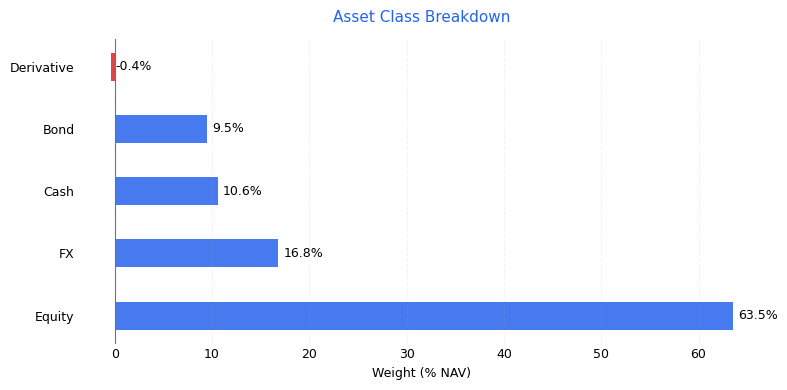

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [ACCENT2 if v < 0 else ACCENT for v in breakdown['weight_pct']]
bars = ax.barh(breakdown.index, breakdown['weight_pct'],
               color=colors, height=0.45, alpha=0.85)
ax.axvline(0, color='#6b7280', lw=0.8)
ax.set_xlabel('Weight (% NAV)', fontsize=9)
ax.set_title('Asset Class Breakdown', color=ACCENT, fontsize=11, pad=12)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='x', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
for bar, val in zip(bars, breakdown['weight_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. VaR and Expected Shortfall

VaR and ES are computed using Historical and Montecarlo simulation on daily NAV returns.
Under AIFMD there is no regulatory VaR limit, but VaR is monitored against
internal limits defined in the RMP and reported in Annex IV.

- Confidence: 99%
- Horizon: 1-day and 20-day (square root of time scaling)
- Method: historical simulation, 250-day rolling window

> **Monte Carlo VaR**: in production these figures come from a third-party risk
> system (Bloomberg PORT, Aladdin, Axioma) and are consumed directly by the risk
> manager. To preserve the workflow without a live risk system connection, we
> approximate using a multi-factor simulation with a hardcoded covariance matrix
> and first-order sensitivities.

In [8]:
nav_history = query_nav_history(ENGINE, FUND_ID)
nav_history['date'] = pd.to_datetime(nav_history['date'])
pnl = nav_history['pnl_pct'].dropna().values

# historical simulation
var_1d  = var_historical(pnl[-250:], confidence=CONFIDENCE)
var_20d = var_scale(var_1d, horizon=HORIZON)
es_1d   = es_historical(pnl[-250:], confidence=CONFIDENCE)
es_20d  = es_scale(es_1d, horizon=HORIZON)

# monte carlo
mc      = var_montecarlo(risk_df, n_sims=10_000,
                         confidence=CONFIDENCE, horizon=1)
mc_20d  = var_scale(mc['var'], horizon=HORIZON)

print(f"{'Metric':<25} {'1d':>10} {'20d':>10}")
print(f"{'':25} {'(% NAV)':>10} {'(% NAV)':>10}")
print('-' * 46)
print(f"{'VaR Historical':<25} {var_1d*100:>9.2f}% {var_20d*100:>9.2f}%")
print(f"{'VaR Monte Carlo':<25} {mc['var']/NAV*100:>9.2f}% {mc_20d/NAV*100:>9.2f}%")
print(f"{'ES Historical':<25} {es_1d*100:>9.2f}% {es_20d*100:>9.2f}%")
print(f"{'ES Monte Carlo':<25} {mc['es']/NAV*100:>9.2f}% {var_scale(mc['es'],HORIZON)/NAV*100:>9.2f}%")
print('-' * 46)
print(f"{'VaR Hist (EUR)':<25} {var_1d*NAV:>10,.0f} {var_20d*NAV:>10,.0f}")
print(f"{'VaR MC (EUR)':<25} {mc['var']:>10,.0f} {mc_20d:>10,.0f}")

Metric                            1d        20d
                             (% NAV)    (% NAV)
----------------------------------------------
VaR Historical                 1.09%      4.89%
VaR Monte Carlo                1.30%      5.83%
ES Historical                  1.26%      5.62%
ES Monte Carlo                 1.46%      6.52%
----------------------------------------------
VaR Hist (EUR)             1,034,568  4,626,731
VaR MC (EUR)               1,234,205  5,519,533


In [9]:
# MRS-27: VaR backtest
nav_history = query_nav_history(ENGINE, FUND_ID)
nav_history['date'] = pd.to_datetime(nav_history['date'])

pnl   = nav_history['pnl_pct'].dropna().values
dates = nav_history['date'].iloc[1:].reset_index(drop=True)

window        = 250
var_hist      = pd.Series([
    var_historical(pnl[max(0, i-window):i], confidence=0.99)
    for i in range(window, len(pnl))
])
var_param     = pd.Series([
    var_parametric(mu=0, sigma=pnl[max(0, i-window):i].std(),
                   confidence=0.99, dist='t')
    for i in range(window, len(pnl))
])

pnl_aligned   = pnl[window:]
dates_aligned = dates.iloc[window:].reset_index(drop=True)
print(f"Backtest observations : {len(pnl_aligned)}")

Backtest observations : 1749


In [10]:
report = full_backtest_report(
    pnl_series=pd.Series(pnl_aligned),
    var_dict={'Historical': var_hist, 'Parametric': var_param},
    dates=dates_aligned
)
report[['n_obs', 'n_breaches', 'breach_rate', 'expected',
        'kupiec_p', 'christoffersen_p', 'result']]

,n_obs,n_breaches,breach_rate,expected,kupiec_p,christoffersen_p,result
0,1749,20,0.0114,0.010,0.5554,0.4962,PASS
1,1749,20,0.0114,0.025,0.0000,0.4962,FAIL
2,1749,20,0.0114,0.050,0.0000,0.4962,FAIL
3,1749,1,0.0006,0.010,0.0000,0.9730,FAIL
4,1749,1,0.0006,0.025,0.0000,0.9730,FAIL
5,1749,1,0.0006,0.050,0.0000,0.9730,FAIL


In [11]:
esma_full   = exception_report(pd.Series(pnl_aligned), var_hist, confidence=0.99)
n_full      = len(esma_full)
breach_full = n_full / len(pnl_aligned)
zone_full   = 'Green' if n_full <= 4 else 'Amber' if n_full <= 9 else 'Red'

print(f"Internal backtest — full history ({len(pnl_aligned)} days)")
print(f"Breaches    : {n_full}")
print(f"Breach rate : {breach_full*100:.2f}% (expected 1.0%)")
print(f"Zone        : {zone_full}")
print()
esma_full

Exception report (99% VaR):
  observations : 1749
  breaches     : 20
  breach rate  : 1.14% (expected 1.0%)
  action       : Review assumptions, document
Internal backtest — full history (1749 days)
Breaches    : 20
Breach rate : 1.14% (expected 1.0%)
Zone        : Red



,date,pnl,var,excess_loss,action
0,106,-0.018788,0.013306,0.005482,"Review assumptions, document"
1,172,-0.022014,0.013306,0.008707,"Review assumptions, document"
2,227,-0.015189,0.013315,0.001874,"Review assumptions, document"
3,290,-0.013899,0.013846,0.000053,"Review assumptions, document"
4,299,-0.016847,0.014557,0.002291,"Review assumptions, document"
5,418,-0.015860,0.014557,0.001303,"Review assumptions, document"
6,639,-0.013191,0.013076,0.000115,"Review assumptions, document"
7,642,-0.016519,0.013297,0.003222,"Review assumptions, document"
8,734,-0.012904,0.012436,0.000468,"Review assumptions, document"
9,934,-0.014349,0.012359,0.001990,"Review assumptions, document"


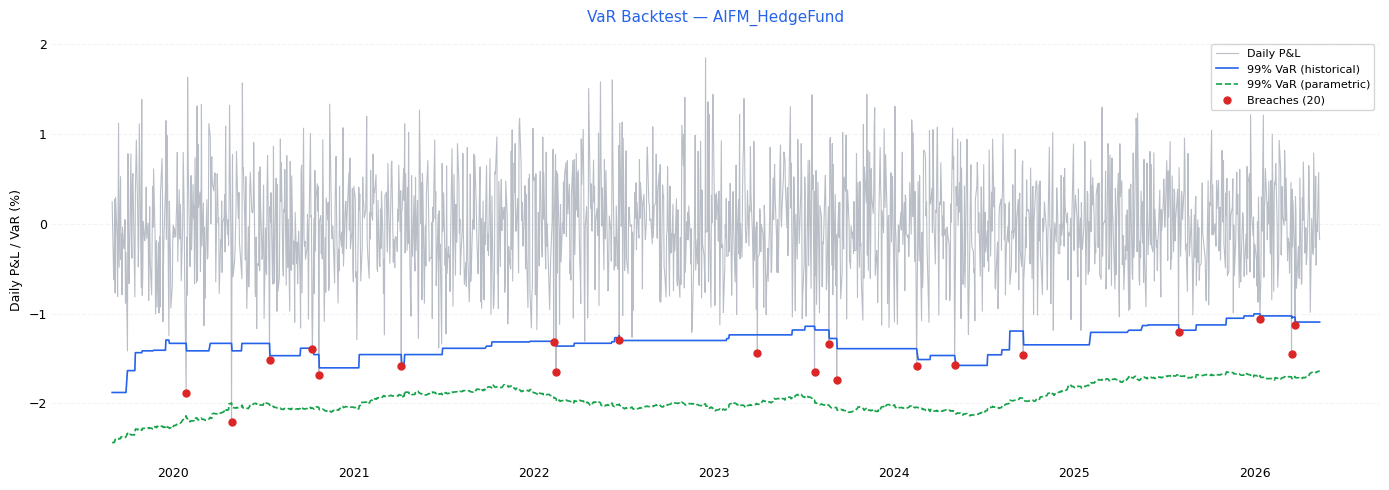

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_aligned, pnl_aligned * 100,
        color='#9ca3af', lw=0.8, label='Daily P&L', alpha=0.7)
ax.plot(dates_aligned, -var_hist * 100,
        color=ACCENT, lw=1.2, label='99% VaR (historical)')
ax.plot(dates_aligned, -var_param * 100,
        color=ACCENT3, lw=1.2, label='99% VaR (parametric)', linestyle='--')

breaches = pnl_aligned < -var_hist.values
ax.scatter(dates_aligned[breaches], pnl_aligned[breaches] * 100,
           color=ACCENT2, s=25, zorder=5, label=f'Breaches ({breaches.sum()})')

ax.set_ylabel('Daily P&L / VaR (%)', fontsize=9)
ax.set_title(f'VaR Backtest — {FUND_ID}', color=ACCENT, fontsize=11, pad=12)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='y', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
esma_250  = exception_report(pd.Series(pnl_aligned[-250:]),
                              var_hist.iloc[-250:], confidence=0.99)
n_250     = len(esma_250)
breach_250 = n_250 / 250
zone_250  = 'Green' if n_250 <= 4 else 'Amber' if n_250 <= 9 else 'Red'

print(f"ESMA regulatory window — last 250 trading days")
print(f"Breaches    : {n_250}")
print(f"Breach rate : {breach_250*100:.2f}% (expected 1.0%)")
print(f"ESMA zone   : {zone_250}")
print()


Exception report (99% VaR):
  observations : 250
  breaches     : 4
  breach rate  : 1.60% (expected 1.0%)
  action       : Review assumptions, document
ESMA regulatory window — last 250 trading days
Breaches    : 4
Breach rate : 1.60% (expected 1.0%)
ESMA zone   : Green



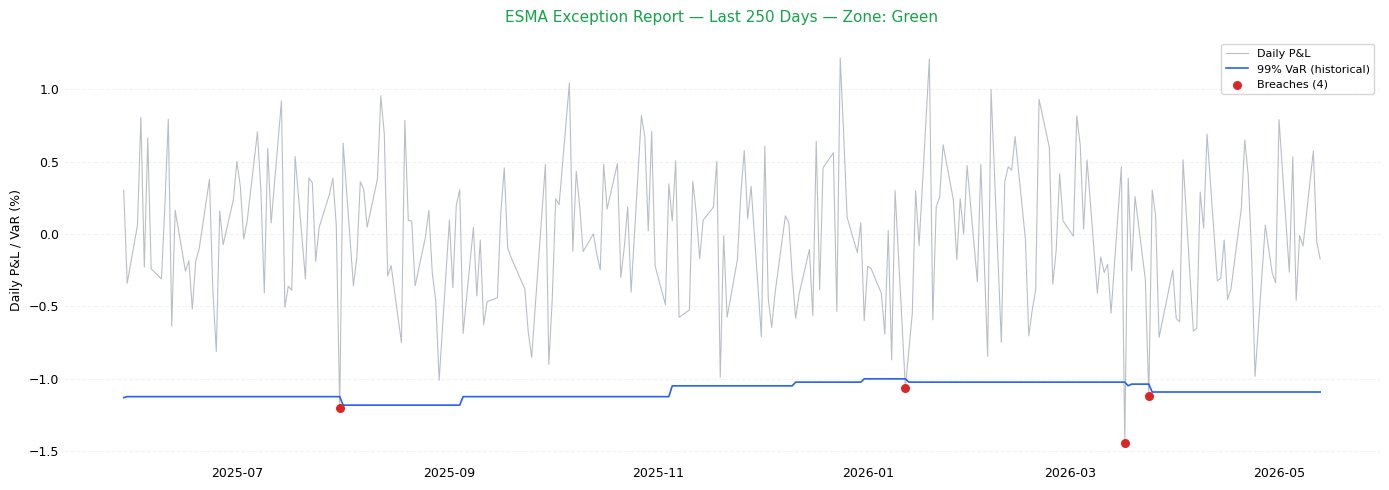

In [14]:
dates_250 = dates_aligned.iloc[-250:].reset_index(drop=True)
pnl_250   = pnl_aligned[-250:]
var_250   = var_hist.iloc[-250:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_250, pnl_250 * 100,
        color='#9ca3af', lw=0.8, label='Daily P&L', alpha=0.7)
ax.plot(dates_250, -var_250 * 100,
        color=ACCENT, lw=1.2, label='99% VaR (historical)')

breaches_250 = pnl_250 < -var_250.values
ax.scatter(dates_250[breaches_250], pnl_250[breaches_250] * 100,
           color=ACCENT2, s=30, zorder=5, label=f'Breaches ({n_250})')

zone_color = {'Green': '#16A34A', 'Amber': '#D97706', 'Red': '#DC2626'}
ax.set_title(f'ESMA Exception Report — Last 250 Days — Zone: {zone_250}',
             color=zone_color[zone_250], fontsize=11, pad=12)
ax.set_ylabel('Daily P&L / VaR (%)', fontsize=9)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='y', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()